In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm import tqdm
import pickle

## Background Solution (Example Calculation)

One can skip this part, it's an example calculation for one stellar model. One can go to the **Dimensionless Tidal Deformability** Section for the complete calculation.

In [2]:
# Load Background Solutions
with open("./numpyArr/Rgrid.pkl", "rb") as f:                        # binary read
    Rgrid = pickle.load(f)

with open("./numpyArr/PMSol.pkl", "rb") as f:                        # binary read
    PMSol = pickle.load(f)

In [3]:
# EOS (energy density vs pressure)
def EnergyEOS(p,K):
    rr=((1+np.sqrt(4*K*p))**2-1)/(4*K)
    return rr

In [4]:
G_cgs = 6.67430e-8     # cm^3 g^-1 s^2
c_cgs = 2.99792458e10  # cm s^-1
M_sun_cgs = 1.989e33   # g
cm2km = 1e5

def cgs_to_geom(p_cgs, n, K_cgs, eos=EnergyEOS):

    # km^-2
    p_geom = p_cgs * G_cgs / c_cgs**4 * cm2km**2            
    # km^(2/n)
    K_geom = K_cgs / G_cgs**(1/n) / c_cgs**(2-2/n) / cm2km**(2/n)               
    # Polytropic EOS, km^-2
    rho_geom = eos(p_geom, K_geom)               

    return K_geom, p_geom, rho_geom

K_cgs = 1.6e5
PcArr = np.logspace(33.5, 36.5, 20)

# used to confirm the unit conversion is correct.
PcConfirm = [np.array(sol)[0,1] for sol in PMSol] 

In [5]:
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

solToUseID = 3 #
PMSolArr = np.array(PMSol[solToUseID])

# Pick the example background to use
RArr = np.array(Rgrid[solToUseID])
PArr = PMSolArr[:,1]
MArr = PMSolArr[:,0]

# Calculating the rho Array
RhoArr = EnergyEOS(PArr, K)

# Calculating the Lambda Array
LambArr = np.log( RArr/ (RArr-2*MArr) )

In [6]:
# Calculating the Sound Speed Array, note this is one dimension less than the original array

DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
DpArr = np.gradient(PArr, RArr, edge_order=2)
Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)


In [7]:
# Cs2Arr[-10:],(np.diff(PArr)/np.diff(RhoArr))[-10:], np.gradient(PArr, RhoArr, edge_order=1)[-10:]

In [8]:
# Cs2Arr.shape, RhoArr.shape,RArr.shape, Drho.shape, DpArr.shape

In [9]:
# Calculating nu by matching solution at stellar surface
def nu_rhs(r, y, p, m):
    rr = 2 * (m + 4*np.pi*(r**3)) / (r*(r-2*m))
    return rr

# the new rk4 function for computing \nu numerically 
def rk4_step_nu(func, r, y, h, p, m):
    k1 = np.array(func(r, y, p, m))
    k2 = np.array(func(r + h/2, y + h*k1/2, p, m))
    k3 = np.array(func(r + h/2, y + h*k2/2, p, m))
    k4 = np.array(func(r + h, y + h*k3, p, m))
    return y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)

In [10]:
# The initial \nu_c we pick is 0
Sol_nu = np.zeros(len(RArr)) 


h = 10**(-3.5)

counter = 0
for i, r in enumerate(RArr[:-1]):

    newStep = rk4_step_nu(nu_rhs, r, Sol_nu[i], h, PMSolArr[i,1], PMSolArr[i,0])
    Sol_nu[i+1] = newStep
    
    counter += 1
    if counter % 10000 == 0: print(counter, newStep)

nu_R = np.log(1-2*PMSolArr[-2,0]/RArr[-2])
print(nu_R)


nuArr = Sol_nu + (nu_R - Sol_nu[-2])
dnuArr = np.gradient(nuArr, RArr, edge_order=2)

10000 126.6483856482918
20000 517.6601241611601
30000 1200.9472252153307
40000 2203.9866671223294
50000 3527.559619186487
-0.1491257511882116


The background equation are all obtained, with variables being
* $\nu$: `nuArr`;
* $\lambda$: `LambArr`;
* $r$: `RArr`;
* $p$: `PArr`;
* $m$: `MArr`;
* $\rho$: `RhoArr`
* $c_s^2$: `Cs2Arr`


## Solve for the perturbation of $0^{th}$ order in $\omega$

Technically, there is only one differential equation to solve, which is $h_{00}$. With the numerical solution of $h_{00}$ and it's derivative, one is able to obtain the value of $w_0$ through a algebraic equation, and $v_0$ through another algebraic equation after calculating $w_0'$. 

$
h_{00}''(r)
+\frac{1 + e^{\Lambda(r)} + 4\pi r^{2} e^{\Lambda(r)}\,p_{0}(r)
      - 4\pi r^{2} e^{\Lambda(r)}\,\rho_{0}(r)}{r}\,h_{00}'(r)
-\frac{\mathcal{A}(r)}{r^{2}\,\bigl(-1 + e^{\Lambda(r)} + 8\pi r^{2} e^{\Lambda(r)}\,p_{0}(r)\bigr)}\,h_{00}(r)
=0
$

\begin{align*}\mathcal{A}(r) &= -1 - 3e^{\Lambda} + 3e^{2\Lambda} + e^{3\Lambda}
+ 96\,\pi^{2} r^{4} e^{2\Lambda}\,(-5 + 2e^{\Lambda})\,p_{0}^{2} \\
&\quad + 512\,\pi^{3} r^{6} e^{3\Lambda}\,p_{0}^{3}
- 20\,\pi r^{2} e^{\Lambda}\,(-1 + e^{\Lambda})\,\rho_{0} \\
&\quad + 4\,\pi r^{2} e^{\Lambda}\,p_{0}\,\bigl(15 - 9e^{\Lambda} + 6 e^{2\Lambda}
      - 40\,\pi r^{2} e^{\Lambda}\,\rho_{0}\bigr)
+ 8\,\pi r^{3} e^{\Lambda}\,\rho_{0}'.
\end{align*}

By approximating the the behavior of the solution at small $r$ with polynomials $h_{00} = a_0 + a_1r + a_2r^2 + a_3r^3$, I noticed that we need to require 

$$a_2 \;\mapsto\; -\,\frac{4\,a_0\,e^{\lambda(r)}\,\pi\;\big(-13\,p_0(r)+4\,e^{\lambda(r)}\,p_0(r)-5\,\rho_0(r)\big)}{-3+2\,e^{\lambda(r)}+e^{2\lambda(r)}}
$$

In [11]:
def h00pp_rhs(r, y, p_r, rho_r, lamb_r, drho, h = 10**(-3.5)):

    def A(r):
        lamb = lamb_r
        eL  = np.exp(lamb)
        e2L = eL*eL
        e3L = e2L*eL
        pr  = p_r
        rr  = rho_r
        rrp = drho
        pi  = np.pi
        r2, r3, r4, r6 = r*r, r*r*r, (r*r)*(r*r), (r*r*r)*(r*r*r)

        term = (
            -1.0 - 3.0*eL + 3.0*e2L + e3L
            + 96.0*e2L*(-5.0 + 2.0*eL)*(pi**2)*r4*(pr**2)
            + 512.0*e3L*(pi**3)*r6*(pr**3)
            - 20.0*eL*(-1.0 + eL)*pi*r2*rr
            + 4.0*eL*pi*r2*pr*(15.0 - 9.0*eL + 6.0*e2L - 40.0*eL*pi*r2*rr)
            + 8.0*eL*pi*r3*rrp
        )
        return term
    
    def denom_D(r):
        eL = np.exp(lamb_r)
        return r*r * (-1.0 + eL + 8.0*eL*np.pi*(r*r)*p_r)
    
    def hp_coeff(r):
        # multiplies h00'
        eL = np.exp(lamb_r)

        return (1.0 + eL + 4.0*eL*np.pi*(r*r)*p_r - 4.0*eL*np.pi*(r*r)*rho_r) / r
    
    def f(r, y):
        y1, y2 = y  # y1 = h00, y2 = h00'
                    
        D = denom_D(r)
        if D == 0.0 or not np.isfinite(D):
            raise ZeroDivisionError(f"Singular denominator at r={r}. Adjust domain or background.")
        
        y1_src = A(r) / D
        y2_src = -hp_coeff(r)
        # y' = [y2, y1_src*y1 + y2_src*y2]

        return np.array([y2, y1_src*y1 + y2_src*y2], dtype=float)
    

    return f(r, y)

In [12]:
def Hinderer25(r, y, p_r, R, rho_r, lamb_r, dnu, cs2, h = 10**(-3.5)):

    lamb = lamb_r
    eL  = np.exp(lamb)
    rr  = rho_r
    pi  = np.pi
    r2 = r*r


    def HpCoeff(r):

        hpc = (2 / r) 

        return hpc
    
    def HCoeff(r):
        
        hp = -6/r2 + pi**2/R**2

        return hp
    
    def f(r, y):

        y1, y2 = y  # y1 = h00, y2 = h00'
        
        y1_src = - HCoeff(r)
        y2_src = - HpCoeff(r)

        return np.array([y2, y1_src*y1 + y2_src*y2], dtype=float)
    

    return f(r, y)

In [13]:
h = 10**(-3.5)

# Minimal fixed-step RK4 integrator
def rk4_step(f, x, y, h, **kwargs):

    k1 = f(x,            y,             **kwargs)
    k2 = f(x + 0.5*h,    y + 0.5*h*k1,  **kwargs)
    k3 = f(x + 0.5*h,    y + 0.5*h*k2,  **kwargs)
    k4 = f(x + h,        y + h*k3,      **kwargs)

    return y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)


55090it [00:00, 58344.02it/s]


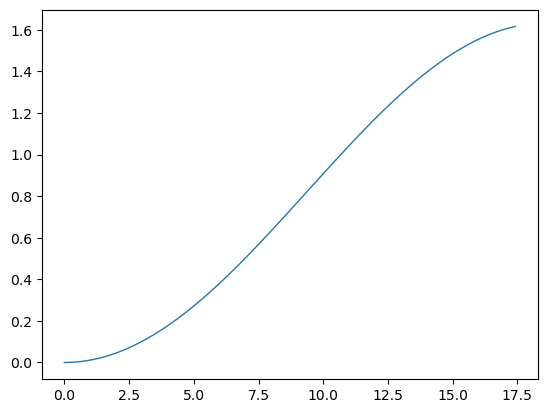

In [14]:
H00ini = np.array([RArr[0]**2, 2*RArr[0]])  # Initial Condition h00(r0)=0, h00'(r0)=0 
H00SolH25 = np.zeros((RArr[1:].shape[0],2))
H00SolH25[0] = H00ini

for i, r in tqdm(enumerate(RArr[1:-2])):

    # p_r, m_r, rho_r, lamb_r, dnu, cs2
    params = {"p_r": PArr[i+1], "R": RArr[-2], "rho_r": RhoArr[i+1], "lamb_r": LambArr[i+1], "dnu": dnuArr[i], "cs2": Cs2Arr[i], "h": h}

    H00SolH25[i+1] = rk4_step(Hinderer25, r, H00SolH25[i], **params)

    r += h

plt.plot(RArr[:-5], H00SolH25[:-4,0], lw=1)

In [15]:
H00Sol = np.zeros((RArr[1:].shape[0],2))
H00Sol[0] = H00ini

for i, r in tqdm(enumerate(RArr[1:-2])):

    params = {"p_r": PArr[i+1], "rho_r": RhoArr[i+1], "lamb_r": LambArr[i+1], "drho": DrhoArr[i], "h": h}

    H00Sol[i+1] = rk4_step(h00pp_rhs, r, H00Sol[i], **params)

    r += h

55090it [00:01, 28114.74it/s]


In [16]:
def HindererH00(r, y, p_r, m_r, rho_r, lamb_r, dnu, cs2, h=10**(-3.5)):
    eL  = np.exp(lamb_r)
    pr  = p_r
    rr  = rho_r
    m   = m_r
    pi  = np.pi

    def HpCoeff(r_local):
        r2_local = r_local * r_local
        return (2.0 / r_local) + eL * ((2.0 * m / r2_local) + 2.0 * pi * r_local * (pr - rr))

    def HCoeff(r_local):
        r2_local = r_local * r_local
        return (-6.0 * eL / r2_local) + 4.0 * pi * eL * (5.0 * pr + 9.0 * rr + (pr + rr) / cs2) - dnu**2

    def f(r_local, y_local):
        y1, y2 = y_local  # y1 = H, y2 = H'
        return np.array([y2, -HCoeff(r_local) * y1 - HpCoeff(r_local) * y2], dtype=float)

    return f(r, y)

# behavior near r=0 --> H ~ A r^2, H' ~ 2A r
H00ini = np.array([RArr[0]**2, 2.0*RArr[0]])

H00SolH = np.zeros((RArr[1:].shape[0], 2), dtype=float)
H00SolH[0] = H00ini

for i, r in tqdm(enumerate(RArr[1:-2])):
    params = {
        "p_r":   PArr[i+1],
        "m_r":   MArr[i+1],
        "rho_r": RhoArr[i+1],
        "lamb_r":LambArr[i+1],
        "dnu":   dnuArr[i+1],   # use i+1 to align with r
        "cs2":   Cs2Arr[i+1],
        "h": h
    }
    H00SolH[i+1] = rk4_step(HindererH00, r, H00SolH[i], **params)


22612it [00:00, 44609.66it/s]/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_74487/523680297.py:11: RuntimeWarning: overflow encountered in add
  return y + (h/6.0)*(k1 + 2*k2 + 2*k3 + k4)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_74487/523680297.py:7: RuntimeWarning: invalid value encountered in add
  k2 = f(x + 0.5*h,    y + 0.5*h*k1,  **kwargs)
55090it [00:01, 46934.00it/s]


In [17]:
# H00ini = np.array([RArr[0]**2, 2*RArr[0]])  # Initial Condition h00(r0)=0, h00'(r0)=0 
# H00Sol = np.zeros((RArr[1:].shape[0],2))
# H00Sol[0] = H00ini

# for i, r in tqdm(enumerate(RArr[1:-2])):

#     # p_r, m_r, rho_r, lamb_r, dnu, cs2
#     params = {"p_r": PArr[i+1], "m_r": MArr[i+1], "rho_r": RhoArr[i+1], "lamb_r": LambArr[i+1], "dnu": dnuArr[i], "cs2": Cs2Arr[i], "h": h}

#     H00Sol[i+1] = rk4_step(HindererH00, r, H00Sol[i], **params)

#     r += h

In [18]:
from scipy.special import jve, jv

def BesselSol(r, R, A):
    
    rR = r/R
    prR = np.pi*rR
    
    # Bessel25 = np.sqrt(2/(np.pi* prR)) * (np.sin(prR) * (3/(prR**2) - 1) - (3/prR) * np.cos(prR))
    Bessel25 = jve(5/2, prR)

    return A * np.sqrt(rR) * Bessel25

In [19]:
def TristenEQN17(r, R, A):
    abar = np.pi/4

    term1 = ((4*abar*np.pi * (r**2) - 3*R**2) / (r**3) ) * np.sin((2 * np.sqrt(abar * np.pi) * r) / R)

    term2 = ((6 * np.sqrt(np.pi*abar) * R) / (r**2)) * np.cos((2*np.sqrt(abar * np.pi)* r) / R)

    return A * (term1 + term2)

Text(0, 0.5, '$h_{00}(r)$')

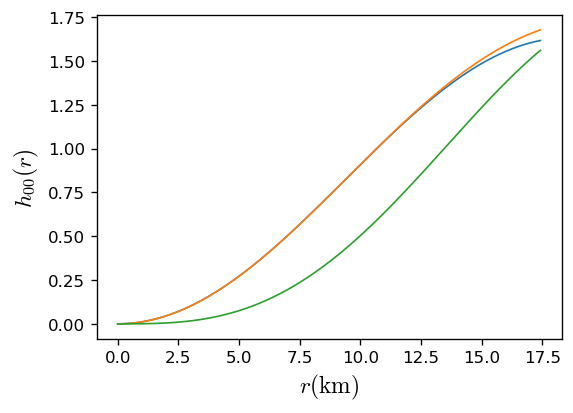

In [20]:
plt.figure(figsize=(5,3.5), dpi=120)

plt.rcParams["mathtext.fontset"] = "cm"


plt.plot(RArr[:-5], H00SolH25[:-4,0], lw=1)
plt.plot(RArr[:-5], H00Sol[:-4,0], lw=1)

# plt.plot(RArr[:-5], TristenEQN17(RArr[:-5], RArr[-2], -2.64), lw=1, color="black", ls="--", alpha=0.5)
plt.plot(RArr[:-2], BesselSol(RArr[:-2], RArr[-2], 3.63), lw=1)

# plt.yscale("log")
# print(BesselSol(RArr[:-2], RArr[-2], 3.64)[:10])

plt.xlabel(r"$r (\text{km})$", fontfamily ="CMU Bright", fontsize=14)
plt.ylabel(r"$h_{00}(r)$", fontfamily ="CMU Bright", fontsize=14)

In [23]:
def K2(C, R, hR, DhR):

    y = R*DhR/hR
    print(y, C, "\n")
    
    term0 = (8/5) * (C**5) * (1 - 2 * (C**2)) * (2 + 2*C*(y - 1) - y)
    
    term1= 2*C * (6 -3*y + 3*C*(5*y - 8))

    term2 = 4 * (C**3) * (13 - 11*y + C*(3*y - 2) + 2 * (C**2) * (1+y))

    term3 = 3 * (1-2*C)**2 * (2 - y + 2*C*(y - 1)) * np.log(1-2*C)

    print(term0, term1, term2, term3)

    return term0 / (term1 + term2 + term3)

In [24]:
K2(MArr[-3]/RArr[-3], RArr[-3], H00Sol[-4,0], H00Sol[-4,1])

0.5012081987173618 0.06927086790114521 

3.6134869019677394e-06 0.46476062420300773 0.009927558753895905 -0.47467050970814156


np.float64(0.20446081819006057)

## Stellar Compactness

In [25]:
# Load Background Solutions
with open("./numpyArr/Rgrid.pkl", "rb") as f:                        # binary read
    Rgrid = pickle.load(f)

with open("./numpyArr/PMSol.pkl", "rb") as f:                        # binary read
    PMSol = pickle.load(f)

In [26]:
def mass_g2Msun(m_km):
    m_cgs = m_km * cm2km
    m_msun = m_cgs / G_cgs * (c_cgs**2) / M_sun_cgs

    return m_msun

/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_74487/1105778859.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), fontfamily="CMU Bright", fontsize=13)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_74487/1105778859.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_yticklabels(axs[i].get_yticklabels(), fontfamily="CMU Bright", fontsize=13)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_74487/1105778859.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[i].set_xticklabels(axs[i].get_xticklabels(), fontfamily="CMU Bright", fontsize=13)
/var/folders/2w/8nb8998n2h38fndcsz3s5wq80000gn/T/ipykernel_74487/1105778859.py:28: UserWarning: set_

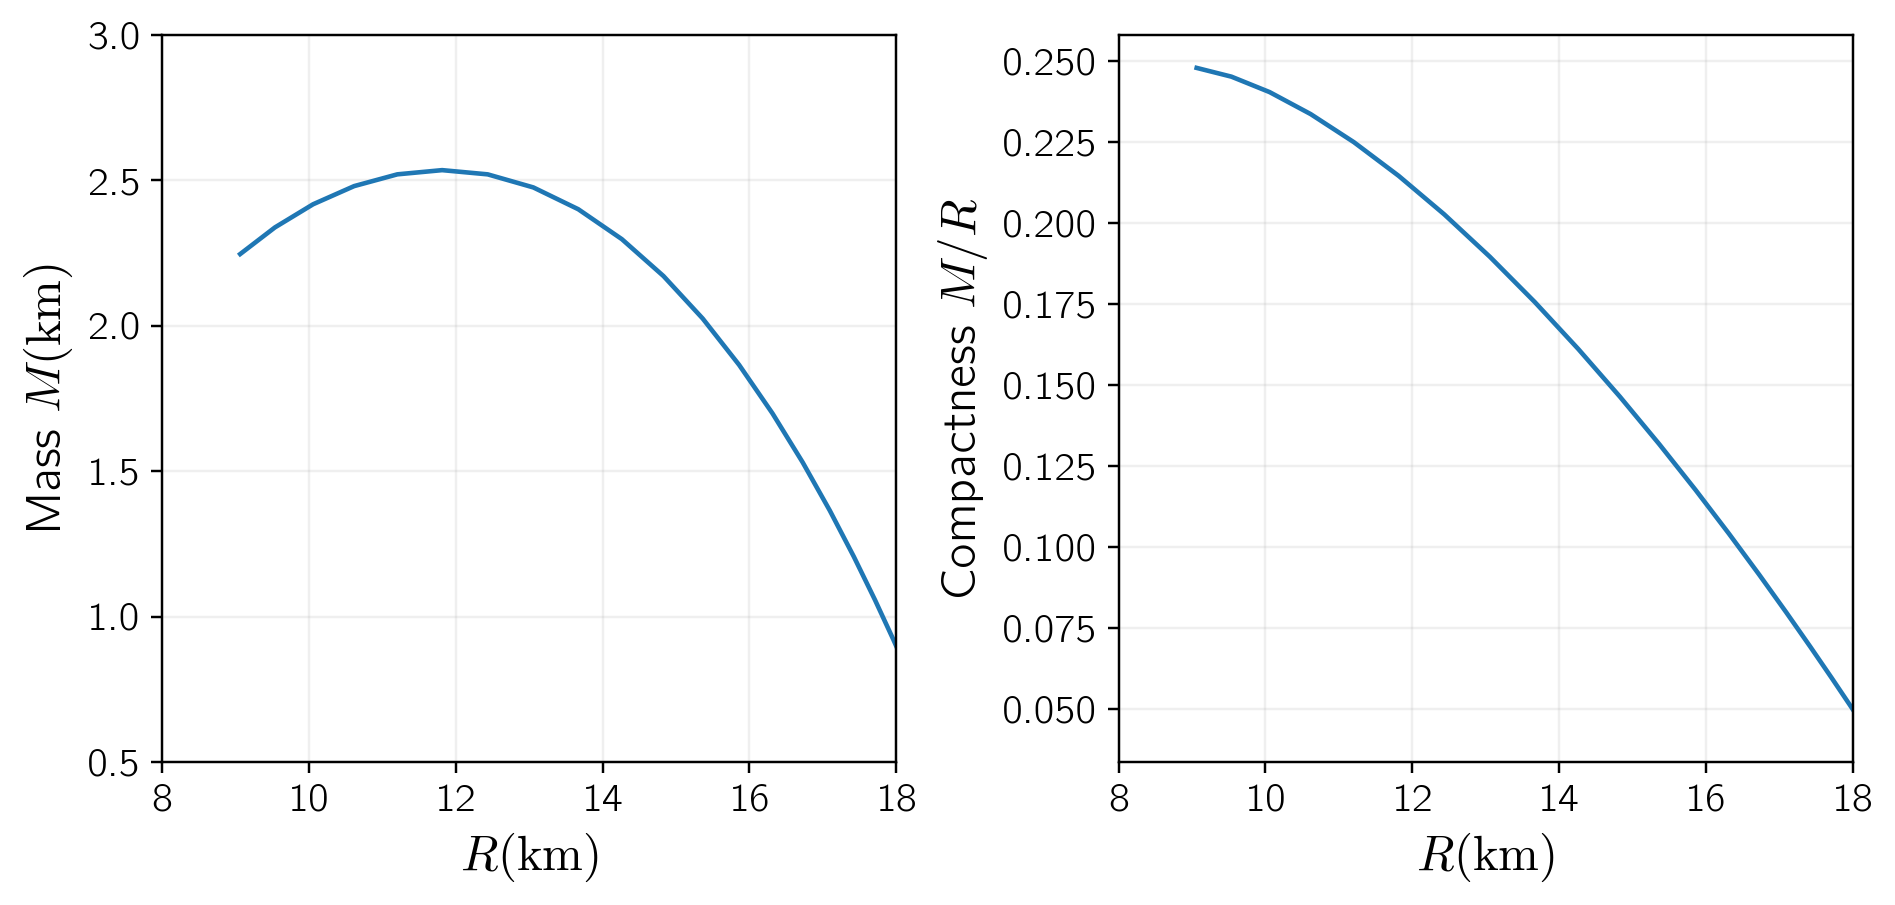

In [27]:
C = np.array([mparr[-2] for mparr, rarr in zip(PMSol, Rgrid)])

  
# plt.figure(figsize=(5,5), dpi=220)
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained")
plt.rcParams["mathtext.fontset"] = "cm"

# plt.plot([rarr[-2] for rarr in Rgrid], mass_g2Msun(C[:,0]))

axs[0].plot([rarr[-2] for rarr in Rgrid], C[:,0])
axs[0].set_ylim(0.5,3)
axs[0].set_xlim(8,18)
axs[0].grid(zorder=-100, alpha=0.2)

axs[0].set_xlabel(r"$R (\text{km})$", fontfamily ="CMU Bright", fontsize=16)
axs[0].set_ylabel(r"Mass $M (\text{km})$", fontfamily ="CMU Bright", fontsize=16)

axs[1].plot([rarr[-2] for rarr in Rgrid], C[:,0]/np.array([rarr[-2] for rarr in Rgrid]))
# axs[1].set_ylim(0.5,3)
axs[1].set_xlim(8,18)
axs[1].grid(zorder=-100, alpha=0.2)

axs[1].set_xlabel(r"$R (\text{km})$", fontfamily ="CMU Bright", fontsize=16)
axs[1].set_ylabel(r"Compactness $M/R$", fontfamily ="CMU Bright", fontsize=16)

for i in [0,1]:
    axs[i].set_xticklabels(axs[i].get_xticklabels(), fontfamily="CMU Bright", fontsize=13)
    axs[i].set_yticklabels(axs[i].get_yticklabels(), fontfamily="CMU Bright", fontsize=13)


In [28]:
CompactnessArr = C[:,0]/np.array([rarr[-2] for rarr in Rgrid])
CompactnessArr[5]

np.float64(0.09151894512168893)

## Dimensionless Tidal Deformability

We numerically integrate $h_{00}$ for all NS models we have.

In [29]:
H00Grid = []

PcArr = np.logspace(33.5, 36.5, 20)
K, PcArr = cgs_to_geom(PcArr, 1, K_cgs)[:2]

In [30]:
for nnn in range(0,20):

    # The stellar model used in the current run
    solToUseID = nnn 
    PMSolArr = np.array(PMSol[solToUseID])

    # Pick the example background to use
    RArr = np.array(Rgrid[solToUseID])
    PArr = PMSolArr[:,1]
    MArr = PMSolArr[:,0]

    # Calculating the rho Array
    RhoArr = EnergyEOS(PArr, K)

    # Calculating the Lambda Array
    LambArr = np.log(RArr/(RArr-2*MArr))

    # Calculating the Sound Speed Array, note this is one dimension less than the original array

    DrhoArr = np.gradient(RhoArr, RArr, edge_order=2)
    DpArr = np.gradient(PArr, RArr, edge_order=2)
    Cs2Arr = np.gradient(PArr, RhoArr, edge_order=2)

    H00ini = np.array([20*RArr[0]**2, 40*RArr[0]])
    H00Sol = np.zeros((RArr[1:].shape[0], 2))
    H00Sol[0] = H00ini

    for i, r in tqdm(enumerate(RArr[1:-2])):

        params = {"p_r": PArr[i+1], "rho_r": RhoArr[i+1], "lamb_r": LambArr[i+1], "drho": DrhoArr[i], "h": h}

        H00Sol[i+1] = rk4_step(h00pp_rhs, r, H00Sol[i], **params)

        r += h
    
    H00Grid.append(H00Sol)

    

57485it [00:01, 29076.92it/s]
56796it [00:02, 23188.88it/s]
56001it [00:01, 29514.40it/s]
55090it [00:01, 27954.89it/s]
54055it [00:02, 24994.36it/s]
52888it [00:02, 26148.26it/s]
51586it [00:01, 26044.37it/s]
50149it [00:01, 25827.22it/s]
48581it [00:01, 24315.33it/s]
46893it [00:01, 25795.93it/s]
45099it [00:01, 23470.31it/s]
43222it [00:01, 21875.38it/s]
41286it [00:01, 23956.33it/s]
39321it [00:01, 22709.57it/s]
37358it [00:01, 22435.58it/s]
35430it [00:01, 22335.94it/s]
33568it [00:01, 19869.99it/s]
31801it [00:01, 21365.32it/s]
30157it [00:01, 21476.54it/s]
28659it [00:01, 20409.53it/s]


In [31]:
# with open("./numpyArr/H00Grid.pkl", "wb") as f:                        
#     pickle.dump(H00Grid, f, protocol=pickle.HIGHEST_PROTOCOL)

In [32]:
# Recalculating D[h00, r, 1], but there's actually no need
# DH00Grid = [np.gradient(H00Grid[i][:,0], Rgrid[i][:-1], edge_order=2) for i in range(0,20)]

$h_{00}$ and its derivative of each stellar model is stored in the variable `H00Grid`, 
* to access it the $h_{00}(r)$ in star $i$, one call `H00Grid[i][:,0]`
* to access it the $h_{00}'(r)$ in star $i$, one call `H00Grid[i][:,1]`

The data is usable from `0th` entry to `-2th` entry - meaning one should not use the data stored at the last index.

In [33]:
# H00R = [H00Grid[i][-1,0] for i in range(0,20)]
# DH00R = [H00Grid[i][-1,1] for i in range(0,20)]
# plt.plot([rarr[-2] for rarr in Rgrid], H00R)
# plt.plot([rarr[-2] for rarr in Rgrid], DH00R)

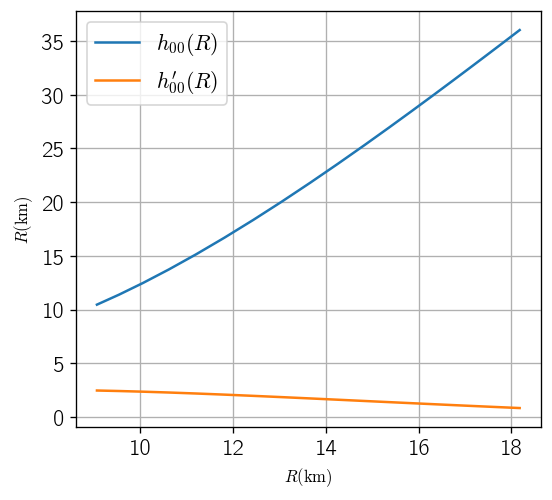

In [34]:
H00R = np.array([H00Grid[i][-2,0] for i in range(0,20)])
DH00R = np.array([H00Grid[i][-2,1] for i in range(0,20)])
RstarArr = np.array([rarr[-2] for rarr in Rgrid])

plt.figure(figsize=(5,4.5), dpi=120)
plt.rcParams["mathtext.fontset"] = "cm"
plt.plot(RstarArr, H00R, label=r"$h_{00}(R)$")
plt.plot(RstarArr, DH00R, label=r"$h_{00}'(R)$")

plt.legend(fontsize=13)
plt.xticks(fontfamily="CMU Bright", fontsize=13)
plt.yticks(fontfamily="CMU Bright", fontsize=13)
plt.xlabel(r"$R (\text{km})$", fontfamily="CMU Bright")
plt.ylabel(r"$R (\text{km})$", fontfamily="CMU Bright")

plt.grid()

In [35]:
def K2(C, R, hR, DhR):

    y = R*DhR/hR
    
    term0 = (8/5) * (C**5) * (1 - 2 * (C**2)) * (2 + 2*C*(y - 1) - y)
    
    term1= 2*C * (6 -3*y + 3*C*(5*y - 8))

    term2 = 4 * (C**3) * (13 - 11*y + C*(3*y - 2) + 2 * (C**2) * (1+y))

    term3 = 3 * (1-2*C)**2 * (2 - y + 2*C*(y - 1)) * np.log(1-2*C)

    return term0 / (term1 + term2 + term3)


def Love(k2, C):

    return (2/3) * k2 / (C**5)

In [36]:
K2Arr = K2(CompactnessArr, RstarArr, H00R, DH00R)
LoveArr = Love(K2Arr, CompactnessArr)
LoveArr

array([9.27369526e+05, 4.11698130e+05, 1.85824669e+05, 8.54773640e+04,
       4.01762055e+04, 1.93435865e+04, 9.56737517e+03, 4.87440845e+03,
       2.56467505e+03, 1.39719499e+03, 7.89702909e+02, 4.64075422e+02,
       2.83916990e+02, 1.81057340e+02, 1.20451621e+02, 8.36632008e+01,
       6.07109854e+01, 4.60652071e+01, 3.65978380e+01, 3.04916283e+01])

In [37]:
def CompactPRD(k2,  a = [0.371, -0.0391, 0.001056]):
    lnk2 = np.log(k2)

    Compactness = a[0] + a[1]*lnk2 + a[2]*(lnk2**2)

    return Compactness

Text(0, 0.5, 'Compactness $C$')

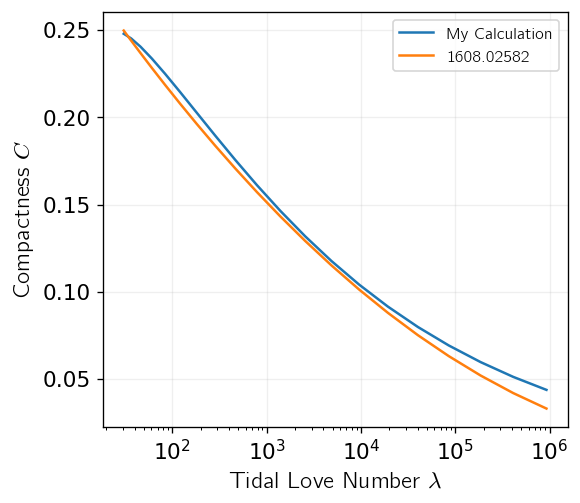

In [38]:
plt.figure(figsize=(5,4.5), dpi=120)
plt.rcParams["mathtext.fontset"] = "cm"

plt.plot(LoveArr, CompactnessArr, label="My Calculation")
plt.plot(LoveArr, CompactPRD(LoveArr), label="1608.02582")
plt.xscale("log")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.legend(prop={"family": "CMU Bright"}, fontsize=14)
plt.grid(alpha=0.2)
plt.xlabel(r"Tidal Love Number $\lambda$", fontfamily="CMU Bright", fontsize=14)
plt.ylabel(r"Compactness $C$", fontfamily="CMU Bright", fontsize=14)



In [39]:
np.mean(CompactPRD(LoveArr) - CompactnessArr), np.std(CompactPRD(LoveArr) - CompactnessArr)

(np.float64(-0.004790450613936151), np.float64(0.0027501715973060562))

Text(0, 0.5, '$(\\tilde{C} - C) - \\overline{\\Delta C}$')

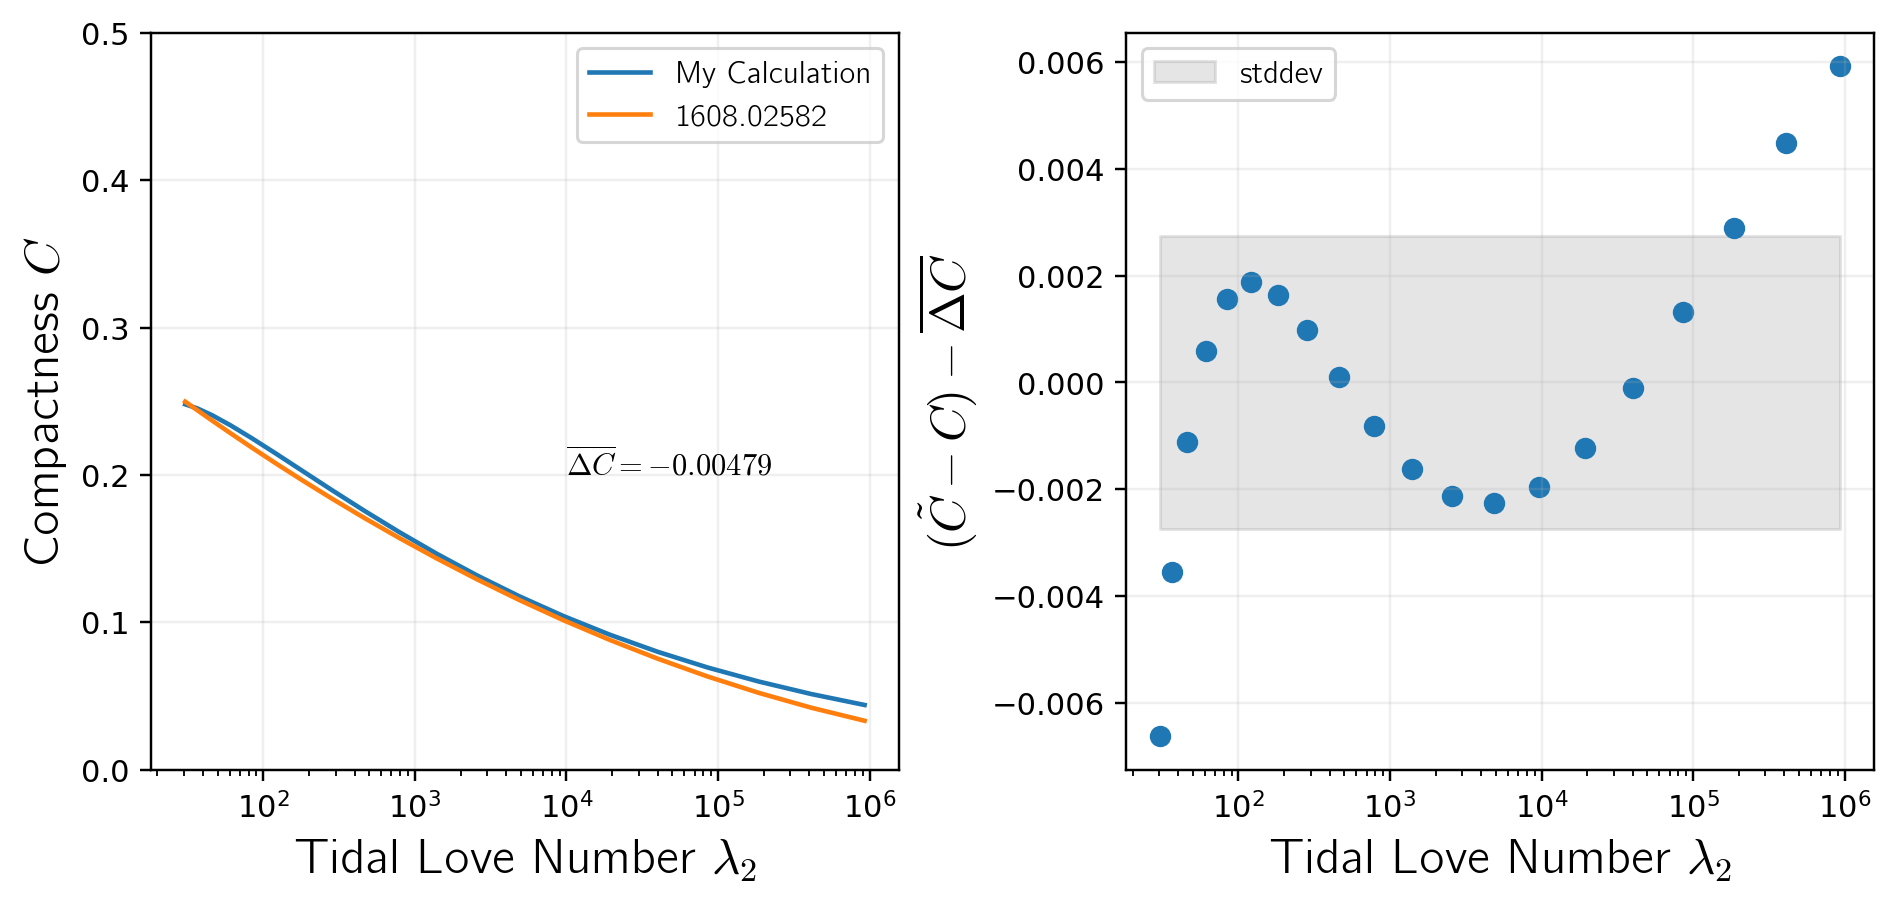

In [40]:
C = np.array([mparr[-2] for mparr, rarr in zip(PMSol, Rgrid)])

  
# plt.figure(figsize=(5,5), dpi=220)
fig, axs = plt.subplots(1, 2, figsize=(8.5, 4), dpi=220, layout="constrained")
plt.rcParams["mathtext.fontset"] = "cm"

# plt.plot([rarr[-2] for rarr in Rgrid], mass_g2Msun(C[:,0]))

axs[0].plot(LoveArr, CompactnessArr, label="My Calculation")
axs[0].plot(LoveArr, CompactPRD(LoveArr), label="1608.02582")
axs[0].set_ylim(0,0.5)
axs[0].set_xscale("log")
axs[0].grid(zorder=-100, alpha=0.2)

axs[0].legend(prop={"family": "CMU Bright"}, fontsize=14)
axs[0].grid(alpha=0.2)

axs[0].set_xlabel(r"Tidal Love Number $\lambda_2$", fontfamily ="CMU Bright", fontsize=16)
axs[0].set_ylabel(r"Compactness $C$", fontfamily ="CMU Bright", fontsize=16)

axs[1].scatter(LoveArr, CompactnessArr - CompactPRD(LoveArr) - np.mean(CompactnessArr -CompactPRD(LoveArr)))

# axs[1].set_ylim(0.5,3)
# axs[1].set_xlim(8,18)
axs[1].set_xscale("log")
axs[1].grid(zorder=-100, alpha=0.2)
axs[1].fill_between(x=LoveArr, y1=np.std(CompactPRD(LoveArr) - CompactnessArr), y2=-np.std(CompactPRD(LoveArr) - CompactnessArr), zorder=-100, alpha=0.2, color="grey", label="stddev")
axs[1].legend(prop={"family": "CMU Bright"}, fontsize=14)
axs[0].text(x=10**4, y=0.2, s=r"$\overline{\Delta C} = -0.00479$")
axs[1].set_xlabel(r"Tidal Love Number $\lambda_2$", fontfamily ="CMU Bright", fontsize=16)
axs[1].set_ylabel(r"$(\tilde{C} - C) - \overline{\Delta C}$", fontfamily ="CMU Bright", fontsize=16)

# for i in [0,1]:
#     axs[i].set_xticklabels(axs[i].get_yticklabels(), fontsize=10)
#     axs[i].set_yticklabels(axs[i].get_yticklabels(), fontsize=10)
